## ***NOTEBOOK PERHITUNGAN PROJECT ANALISIS PORTOFOLIO PADA SAHAM 035900.KQ 041510.KQ 173940.KQ 122870.KQ***


Oleh:

Aliifah Farhah Maajidah
(L0225014)

Fathia Salsabila Arfian
(L0225021)

# **Import sys**

In [ ]:
import sys
!{sys.executable} -m pip install pandas pandas-datareader matplotlib seaborn plotly-express numpy
print("Semua pustaka yang diperlukan telah diinstal.")

Semua pustaka yang diperlukan telah diinstal.


# **Impor semua pustaka**

In [ ]:
import pandas as pd
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import seaborn as sns
import plotly_express as px
import numpy as np
import yfinance as yf
import datetime

print("Semua pustaka yang diperlukan telah diimpor.")

Semua pustaka yang diperlukan telah diimpor.


Mengimpor `yfinance` sebagai`yf` dan menggunakan fungsi download-nya untuk mendapatkan harga `'Adj Close'`, kemudian menampilkan lima baris pertama dan informasi dari DataFrame yang dihasilkan.



# **Akuisisi Data Keuangan**

In [ ]:
# 1. Tentukan daftar simbol ticker saham
tickers = ['035900.KQ', '041510.KQ', '173940.KQ', '122870.KQ']

# 2. Tentukan tanggal mulai dan tanggal akhir
# end_date = datetime.datetime.now()
end_date = pd.to_datetime('02/07/2025')
start_date = end_date - datetime.timedelta(days=5*365)

# 3. Gunakan yfinance untuk mengunduh data harga saham historis
# Menginisialisasi DataFrame kosong untuk menyimpan 'Adj Close' harga
stock_data_yf = pd.DataFrame()

for ticker in tickers:
    try:
        # Download data for a single ticker
        data = yf.download(ticker, start=start_date, end=end_date, progress=False)
        if not data.empty:
            if 'Adj Close' in data.columns:
                stock_data_yf[ticker] = data['Adj Close']
            elif 'Close' in data.columns:
                # Fallback to 'Close' price if 'Adj Close' is not available (e.g., if auto_adjust makes them identical)
                stock_data_yf[ticker] = data['Close']
                print(f"Warning: 'Adj Close' not found for {ticker}, using 'Close' price.")
            else:
                print(f"Could not find 'Adj Close' or 'Close' data for {ticker}.")
        else:
            print(f"No data downloaded for {ticker}.")
    except Exception as e:
        print(f"Error fetching data for {ticker}: {e}")

# Drop any rows with missing values that might occur if some dates are not present for all stocks
stock_data_yf.dropna(inplace=True)

# 4. Tampilkan lima baris pertama dari DataFrame
print("Data harga saham historis (Adj Close) untuk 5 saham:")
print(stock_data_yf.head())

print("\nInformasi DataFrame:\n")
stock_data_yf.info()

/tmp/ipython-input-3776798763.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, progress=False)


/tmp/ipython-input-3776798763.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, progress=False)
/tmp/ipython-input-3776798763.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, progress=False)


Data harga saham historis (Adj Close) untuk 5 saham:
               035900.KQ     041510.KQ  173940.KQ     122870.KQ
Date                                                           
2020-02-10  24878.658203  31965.683594     7850.0  32164.337891
2020-02-11  24781.474609  32538.201172     7850.0  31524.005859
2020-02-12  24635.701172  32681.333984     7800.0  32213.593750
2020-02-13  24344.152344  32442.781250     7870.0  32706.156250
2020-02-14  24392.746094  32395.072266     7890.0  32164.337891

Informasi DataFrame:



/tmp/ipython-input-3776798763.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, progress=False)


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1218 entries, 2020-02-10 to 2025-02-06
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   035900.KQ  1218 non-null   float64
 1   041510.KQ  1218 non-null   float64
 2   173940.KQ  1218 non-null   float64
 3   122870.KQ  1218 non-null   float64
dtypes: float64(4)
memory usage: 47.6 KB


# **Eksplorasi dan Pra-pemrosesan Data**

In [ ]:
print("Informasi Ringkas DataFrame stock_data_yf:")
stock_data_yf.info()

print("\nStatistik Deskriptif DataFrame stock_data_yf:")
print(stock_data_yf.describe())

print("\nJumlah Nilai Hilang per Kolom di stock_data_yf:")
print(stock_data_yf.isnull().sum())

Informasi Ringkas DataFrame stock_data_yf:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1218 entries, 2020-02-10 to 2025-02-06
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   035900.KQ  1218 non-null   float64
 1   041510.KQ  1218 non-null   float64
 2   173940.KQ  1218 non-null   float64
 3   122870.KQ  1218 non-null   float64
dtypes: float64(4)
memory usage: 47.6 KB

Statistik Deskriptif DataFrame stock_data_yf:
           035900.KQ      041510.KQ     173940.KQ     122870.KQ
count    1218.000000    1218.000000   1218.000000   1218.000000
mean    57429.225183   66119.744121   5757.253695  49832.502492
std     26630.427381   28319.688510   1607.889058  12709.522969
min     14917.475586   15935.131836   2710.000000  19160.683594
25%     37967.916016   35806.338867   4920.000000  42512.500000
50%     53461.902344   68065.601562   5810.000000  48211.310547
75%     69881.500000   79405.248047   6190.000000  56102.

## **Menghitung *daily returns, monthly returns,* dan normalisasi data saham**

Dengan ME

In [ ]:
import numpy as np

# Hitung daily returns
daily_returns = stock_data_yf.pct_change().dropna()

# Hitung monthly returns
# Resample data to get the last trading day of each month and calculate percentage change
monthly_returns = stock_data_yf.resample('ME').last().pct_change().dropna()
# Normalisasi data
# Divide each price by the price on the first day for each stock
normalized_stock_data = stock_data_yf / stock_data_yf.iloc[0]

# Tampilkan lima baris pertama dari daily_returns, monthly_returns, dan normalized_stock_data
print("\nLima Baris Pertama Daily Returns:")
print(daily_returns.head())

print("\nLima Baris Pertama Monthly Returns:")
print(monthly_returns.head())

print("\nLima Baris Pertama Normalized Stock Data:")
print(normalized_stock_data.head())


Lima Baris Pertama Daily Returns:
            035900.KQ  041510.KQ  173940.KQ  122870.KQ
Date                                                  
2020-02-11  -0.003906   0.017910   0.000000  -0.019908
2020-02-12  -0.005882   0.004399  -0.006369   0.021875
2020-02-13  -0.011834  -0.007299   0.008974   0.015291
2020-02-14   0.001996  -0.001471   0.002541  -0.016566
2020-02-17   0.019920   0.002946   0.000000   0.059724

Lima Baris Pertama Monthly Returns:
            035900.KQ  041510.KQ  173940.KQ  122870.KQ
Date                                                  
2020-03-31  -0.158392  -0.260105  -0.285922  -0.206271
2020-04-30   0.165730   0.315915   0.231707   0.232848
2020-05-31   0.101205  -0.061372  -0.056106  -0.001686
2020-06-30  -0.072210  -0.067308   0.085664   0.258446
2020-07-31   0.408019   0.288660  -0.017713   0.092617

Lima Baris Pertama Normalized Stock Data:
            035900.KQ  041510.KQ  173940.KQ  122870.KQ
Date                                                  
2020-

# **Visualisasi Data Awal**

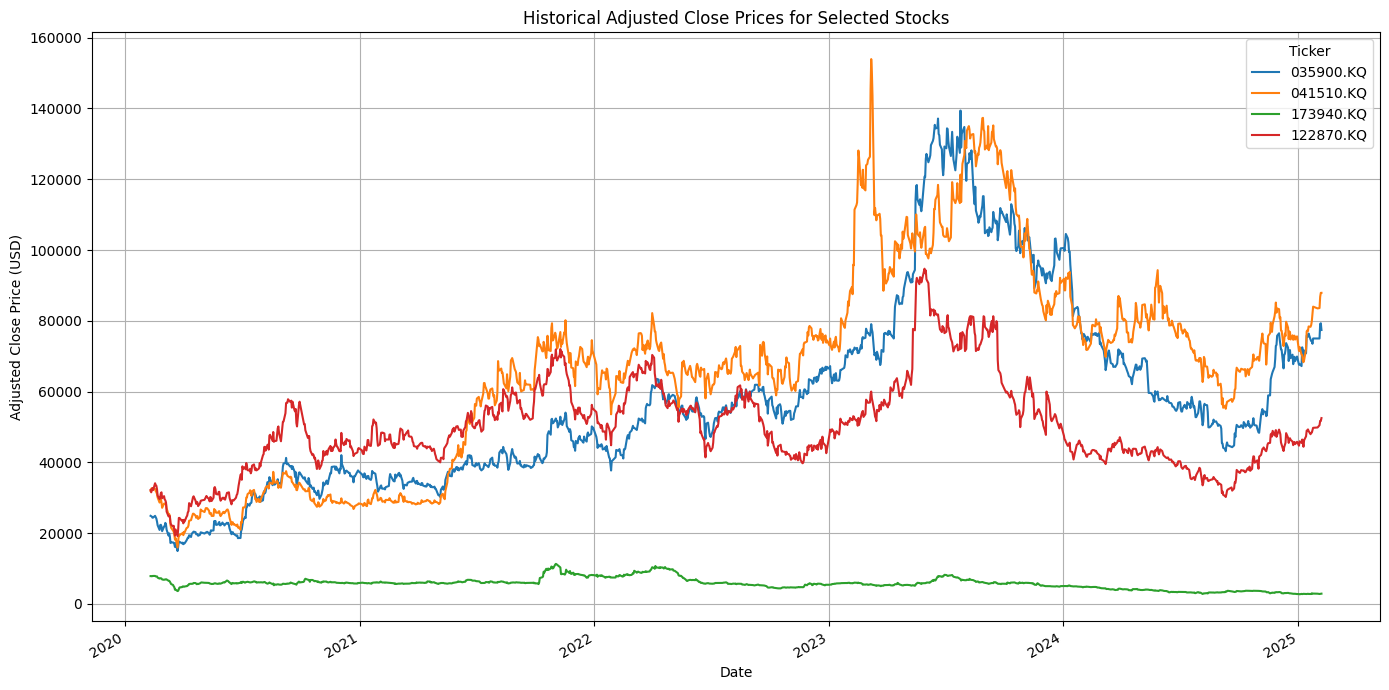

Grafik harga saham historis telah ditampilkan.


In [ ]:
import matplotlib.pyplot as plt # Ensure matplotlib is imported for plotting

# 5. Plot the historical adjusted close prices
plt.figure(figsize=(14, 7))
stock_data_yf.plot(ax=plt.gca())
plt.title('Historical Adjusted Close Prices for Selected Stocks')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price (USD)')
plt.legend(title='Ticker')
plt.grid(True)
plt.tight_layout()
plt.show()

print("Grafik harga saham historis telah ditampilkan.")

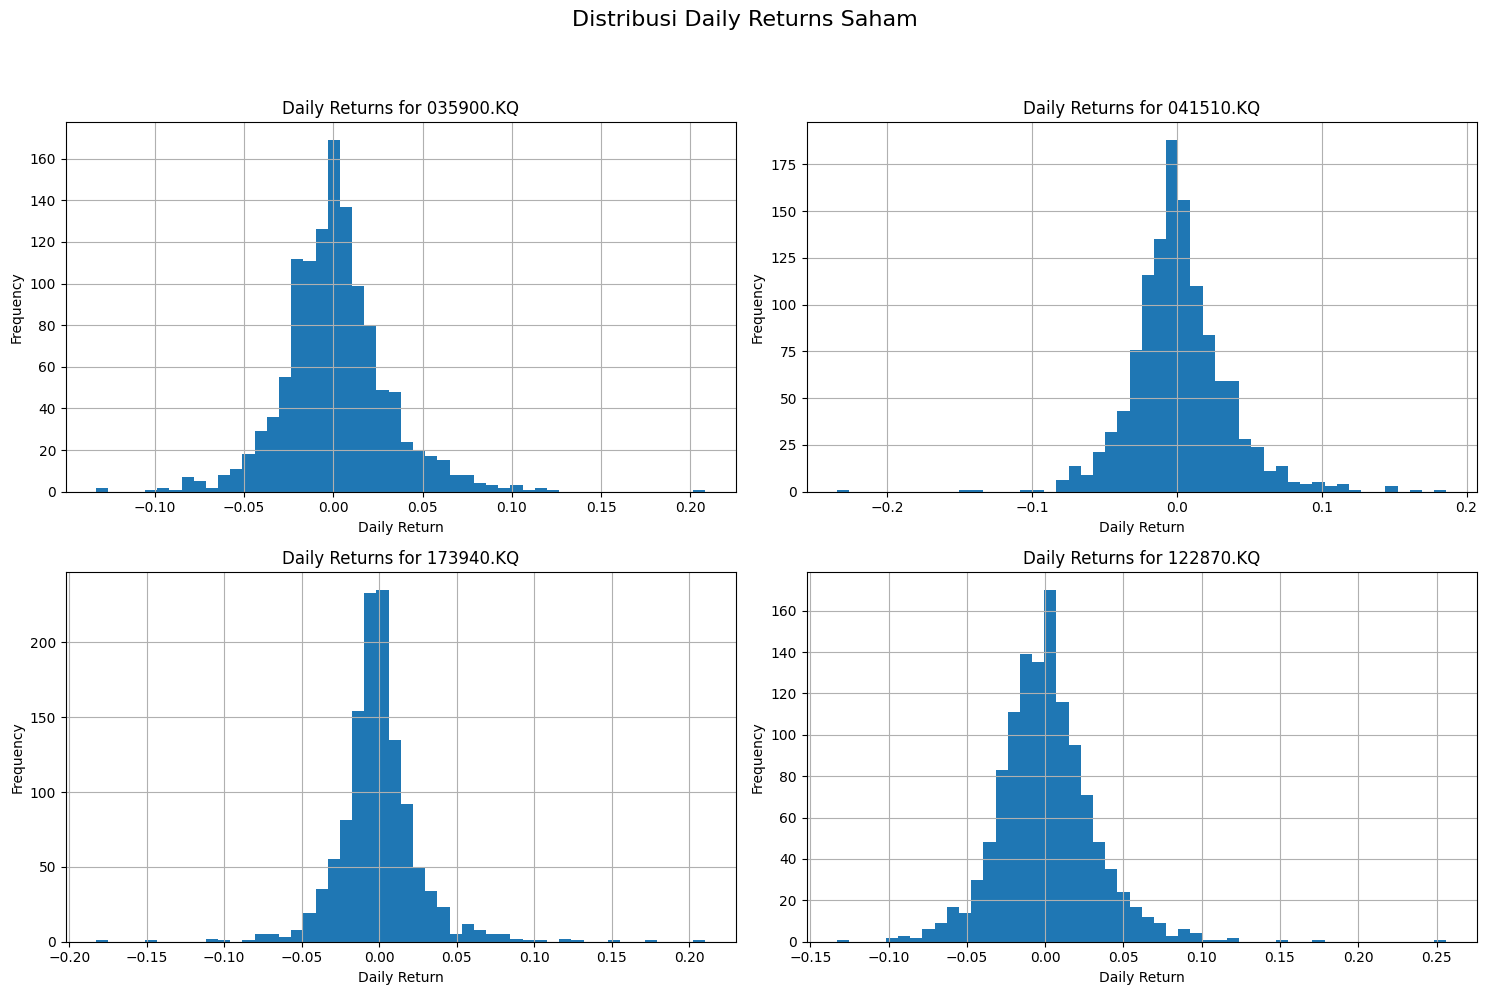

Histograms untuk daily returns telah ditampilkan.


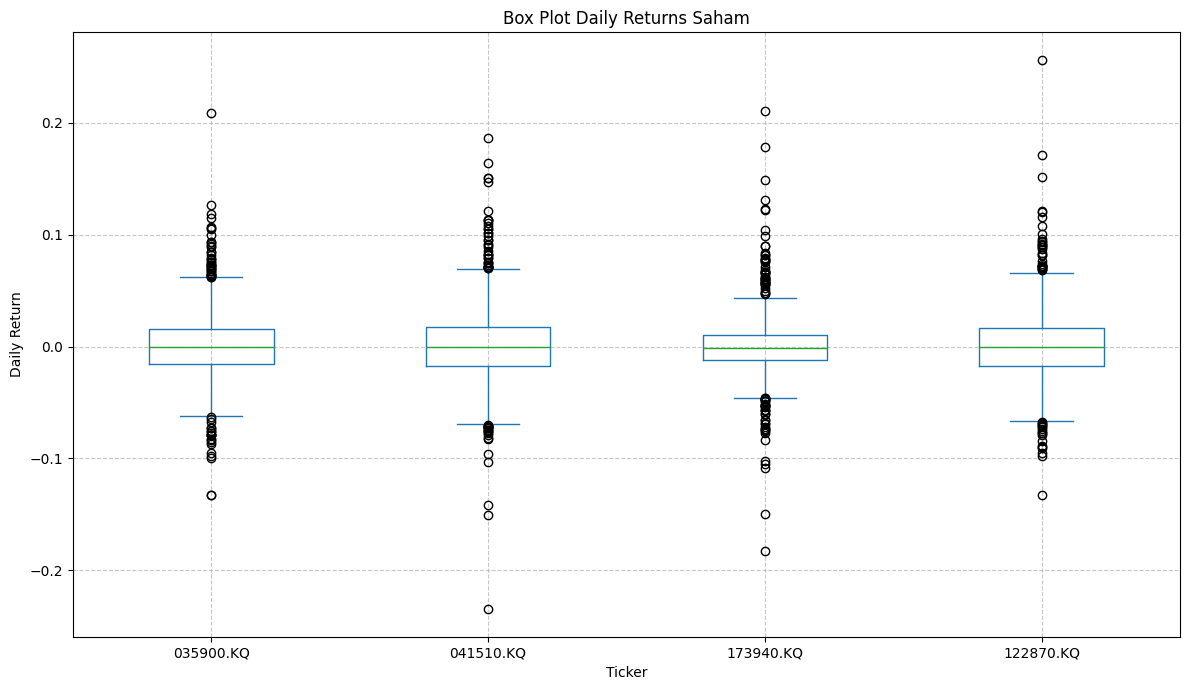

Box plots untuk daily returns telah ditampilkan.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Buat histogram untuk return harian
# daily_returns.hist() automatically creates subplots for each column and returns the Axes objects.
hist_axes = daily_returns.hist(bins=50, figsize=(15, 10)) # Set figsize here

# Get the figure created by daily_returns.hist() to set the suptitle
fig_hist = plt.gcf()
fig_hist.suptitle('Distribusi Daily Returns Saham', y=1.02, fontsize=16)

# Flatten the axes array if it's 2D (e.g., if there are multiple rows of subplots)
if isinstance(hist_axes, (list, np.ndarray)) and len(hist_axes.shape) > 1:
    hist_axes = hist_axes.flatten()

for i, ax in enumerate(hist_axes):
    # Ensure we don't go out of bounds for daily_returns.columns (though hist() should match)
    if i < len(daily_returns.columns):
        ax.set_xlabel('Daily Return')
        ax.set_ylabel('Frequency')
        ax.set_title(f'Daily Returns for {daily_returns.columns[i]}')

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

print("Histograms untuk daily returns telah ditampilkan.")

# 2. Buat box plot untuk return harian
plt.figure(figsize=(12, 7))
daily_returns.plot(kind='box', ax=plt.gca())
plt.title('Box Plot Daily Returns Saham')
plt.xlabel('Ticker')
plt.ylabel('Daily Return')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Box plots untuk daily returns telah ditampilkan.")

## **Visualisasi Data Interaktif**

In [ ]:
import plotly_express as px

# 1. Buat line plot interaktif untuk normalized_stock_data
fig_normalized_prices = px.line(
    normalized_stock_data,
    x=normalized_stock_data.index,
    y=normalized_stock_data.columns,
    title='Perbandingan Harga Saham yang Dinormalisasi (Interaktif)',
    labels={'index': 'Tanggal', 'value': 'Harga Dinormalisasi'},
    hover_name=normalized_stock_data.columns.name # Display ticker name on hover
)

fig_normalized_prices.update_layout(
    xaxis_title='Tanggal',
    yaxis_title='Harga Dinormalisasi'
)

fig_normalized_prices.show()

print("Line plot interaktif untuk harga saham yang dinormalisasi telah ditampilkan.")

Line plot interaktif untuk harga saham yang dinormalisasi telah ditampilkan.


In [ ]:
import plotly_express as px

# 2. Buat histogram interaktif untuk daily_returns

print("Membuat histogram interaktif untuk daily returns setiap saham...")

for col in daily_returns.columns:
    fig_hist_daily_returns = px.histogram(
        daily_returns,
        x=col,
        nbins=50, # Number of bins
        title=f'Distribusi Daily Returns Interaktif untuk {col}',
        labels={col: 'Daily Return', 'count': 'Frekuensi'}
    )
    fig_hist_daily_returns.update_layout(xaxis_title='Daily Return', yaxis_title='Frekuensi')
    fig_hist_daily_returns.show()

print("Histogram interaktif untuk daily returns telah ditampilkan.")

Membuat histogram interaktif untuk daily returns setiap saham...


Histogram interaktif untuk daily returns telah ditampilkan.


## **Perhitungan Metrik Portofolio**

In [ ]:
TRADING_DAYS_PER_YEAR = 252
RISK_FREE_RATE = 0.01 # Asumsi 1% tingkat bebas risiko tahunan

# 2. Hitung Cumulative Return untuk setiap saham
cumulative_returns = (1 + daily_returns).prod() - 1

# 3. Hitung Annual Return untuk setiap saham
# Menggunakan rata-rata aritmetika yang di-annualisasi dari daily returns
annual_returns = daily_returns.mean() * TRADING_DAYS_PER_YEAR

# 4. Hitung Annualized Volatility untuk setiap saham
annualized_volatility = daily_returns.std() * np.sqrt(TRADING_DAYS_PER_YEAR)

# 6. Hitung Sharpe Ratio untuk setiap saham
sharpe_ratios = (annual_returns - RISK_FREE_RATE) / annualized_volatility

# 7. Buat DataFrame untuk menampilkan metrik yang dihitung
portfolio_metrics = pd.DataFrame({
    'Cumulative Return': cumulative_returns,
    'Annual Return': annual_returns,
    'Annualized Volatility': annualized_volatility,
    'Sharpe Ratio': sharpe_ratios
})

print("Metrik Portofolio untuk Setiap Saham:")
print(portfolio_metrics.round(4))

Metrik Portofolio untuk Setiap Saham:
           Cumulative Return  Annual Return  Annualized Volatility  \
035900.KQ             2.1111         0.3462                 0.4735   
041510.KQ             1.7498         0.3505                 0.5323   
173940.KQ            -0.6325        -0.1178                 0.4250   
122870.KQ             0.6322         0.2229                 0.4968   

           Sharpe Ratio  
035900.KQ        0.7101  
041510.KQ        0.6396  
173940.KQ       -0.3007  
122870.KQ        0.4285  


In [ ]:
import numpy as np

# 8. Asumsikan bobot yang sama untuk setiap saham dalam portofolio
# Anda bisa memodifikasi bobot ini untuk analisis sensitivitas
num_assets = len(tickers)
weights = np.array([1/num_assets] * num_assets)

# Pastikan bobot yang digunakan memiliki indeks kolom yang sama dengan daily_returns
weights_df = pd.Series(weights, index=daily_returns.columns)

# 9. Hitung daily returns portofolio
portfolio_daily_returns = daily_returns.dot(weights)

# Tampilkan lima baris pertama daily returns portofolio
print("Lima Baris Pertama Daily Returns Portofolio:")
print(portfolio_daily_returns.head())

Lima Baris Pertama Daily Returns Portofolio:
Date
2020-02-11   -0.001476
2020-02-12    0.003506
2020-02-13    0.001283
2020-02-14   -0.003375
2020-02-17    0.020648
dtype: float64


In [ ]:
import numpy as np

# 10. Hitung Cumulative Return Portofolio
portfolio_cumulative_return = (1 + portfolio_daily_returns).prod() - 1

# 11. Hitung Annual Return Portofolio
portfolio_annual_return = portfolio_daily_returns.mean() * TRADING_DAYS_PER_YEAR

# 12. Hitung Annualized Volatility Portofolio
portfolio_annualized_volatility = portfolio_daily_returns.std() * np.sqrt(TRADING_DAYS_PER_YEAR)

# 13. Hitung Sharpe Ratio Portofolio
portfolio_sharpe_ratio = (portfolio_annual_return - RISK_FREE_RATE) / portfolio_annualized_volatility

# 14. Tampilkan metrik portofolio
print("\nMetrik Keseluruhan Portofolio (Bobot Sama):")
print(f"Cumulative Return: {portfolio_cumulative_return:.4f}")
print(f"Annual Return: {portfolio_annual_return:.4f}")
print(f"Annualized Volatility: {portfolio_annualized_volatility:.4f}")
print(f"Sharpe Ratio: {portfolio_sharpe_ratio:.4f}")


Metrik Keseluruhan Portofolio (Bobot Sama):
Cumulative Return: 0.8658
Annual Return: 0.2005
Annualized Volatility: 0.3780
Sharpe Ratio: 0.5039


## **Analisis dan Optimalisasi Portofolio**

In [ ]:
import numpy as np
import pandas as pd

# 1. Tetapkan jumlah simulasi portofolio
num_portfolios = 10000 # Contoh: 10.000 atau 20.000

# Inisialisasi daftar kosong untuk menyimpan hasil simulasi
portfolio_returns = []
portfolio_volatility = []
portfolio_sharpe_ratios = []
portfolio_weights = []

# Dapatkan jumlah aset dari daily_returns
num_assets = len(daily_returns.columns)

# Hitung rata-rata return harian dan matriks kovarian
mean_daily_returns = daily_returns.mean()
cov_matrix_daily = daily_returns.cov()

# Loop untuk simulasi
for portfolio in range(num_portfolios):
    # a. Hasilkan bobot acak untuk setiap aset
    weights = np.random.random(num_assets)
    weights = weights / np.sum(weights) # Normalisasi agar jumlahnya 1

    portfolio_weights.append(weights)

    # b. Hitung return portofolio tahunan
    # Annualize mean daily returns first
    annual_returns_individual = mean_daily_returns * TRADING_DAYS_PER_YEAR
    portfolio_annual_return = np.sum(annual_returns_individual * weights)
    portfolio_returns.append(portfolio_annual_return)

    # c. Hitung volatilitas portofolio tahunan
    # Annualize covariance matrix by multiplying by TRADING_DAYS_PER_YEAR
    portfolio_annual_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix_daily * TRADING_DAYS_PER_YEAR, weights)))
    portfolio_volatility.append(portfolio_annual_volatility)

    # d. Hitung Sharpe Ratio portofolio
    sharpe_ratio = (portfolio_annual_return - RISK_FREE_RATE) / portfolio_annual_volatility
    portfolio_sharpe_ratios.append(sharpe_ratio)

# 4. Buat DataFrame dari hasil simulasi
portfolio_results = pd.DataFrame({
    'Return': portfolio_returns,
    'Volatility': portfolio_volatility,
    'Sharpe Ratio': portfolio_sharpe_ratios
})

# Tambahkan kolom bobot ke DataFrame
for i, col in enumerate(daily_returns.columns):
    portfolio_results[col + ' Weight'] = [w[i] for w in portfolio_weights]

print("Lima baris pertama hasil simulasi portofolio:")
print(portfolio_results.head())

# 5. Identifikasi portofolio optimal dan risiko minimum
# Portofolio dengan Sharpe Ratio tertinggi
optimal_portfolio = portfolio_results.loc[portfolio_results['Sharpe Ratio'].idxmax()]

# Portofolio dengan volatilitas terendah
min_volatility_portfolio = portfolio_results.loc[portfolio_results['Volatility'].idxmin()]

# 6. Cetak metrik untuk portofolio optimal dan risiko minimum
print("\n======================================================")
print("Portofolio Optimal (Sharpe Ratio Tertinggi):")
print("------------------------------------------------------")
print(f"Annual Return: {optimal_portfolio['Return']:.4f}")
print(f"Annualized Volatility: {optimal_portfolio['Volatility']:.4f}")
print(f"Sharpe Ratio: {optimal_portfolio['Sharpe Ratio']:.4f}")
print("Weights:")
for col in daily_returns.columns:
    print(f"  {col}: {optimal_portfolio[col + ' Weight']:.4f}")
print("======================================================")

print("\n======================================================")
print("Portofolio Risiko Minimum:")
print("------------------------------------------------------")
print(f"Annual Return: {min_volatility_portfolio['Return']:.4f}")
print(f"Annualized Volatility: {min_volatility_portfolio['Volatility']:.4f}")
print(f"Sharpe Ratio: {min_volatility_portfolio['Sharpe Ratio']:.4f}")
print("Weights:")
for col in daily_returns.columns:
    print(f"  {col}: {min_volatility_portfolio[col + ' Weight']:.4f}")
print("======================================================")

Lima baris pertama hasil simulasi portofolio:
     Return  Volatility  Sharpe Ratio  035900.KQ Weight  041510.KQ Weight  \
0  0.245696    0.411031      0.573426          0.360255          0.090881   
1  0.101541    0.355826      0.257264          0.262602          0.039123   
2  0.153951    0.375893      0.382956          0.177804          0.395437   
3  0.169178    0.410334      0.387924          0.022463          0.111174   
4  0.130622    0.378764      0.318462          0.102125          0.061892   

   173940.KQ Weight  122870.KQ Weight  
0          0.097496          0.451368  
1          0.465917          0.232358  
2          0.414865          0.011894  
3          0.207387          0.658976  
4          0.330960          0.505023  

Portofolio Optimal (Sharpe Ratio Tertinggi):
------------------------------------------------------
Annual Return: 0.3390
Annualized Volatility: 0.4461
Sharpe Ratio: 0.7375
Weights:
  035900.KQ: 0.6206
  041510.KQ: 0.3306
  173940.KQ: 0.0078
  122870

In [ ]:
display(portfolio_results)

,Return,Volatility,Sharpe Ratio,035900.KQ Weight,041510.KQ Weight,173940.KQ Weight,122870.KQ Weight
0,0.245696,0.411031,0.573426,0.360255,0.090881,0.097496,0.451368
1,0.101541,0.355826,0.257264,0.262602,0.039123,0.465917,0.232358
2,0.153951,0.375893,0.382956,0.177804,0.395437,0.414865,0.011894
3,0.169178,0.410334,0.387924,0.022463,0.111174,0.207387,0.658976
4,0.130622,0.378764,0.318462,0.102125,0.061892,0.330960,0.505023
...,...,...,...,...,...,...,...
9995,0.217203,0.382681,0.541451,0.348264,0.301973,0.255892,0.093871
9996,0.221218,0.406345,0.519801,0.222115,0.129965,0.133966,0.513954
9997,0.061463,0.358303,0.143630,0.116086,0.042808,0.531889,0.309217
9998,0.132079,0.389018,0.313812,0.003731,0.508302,0.458319,0.029647


## **Visualisasi Hasil Analisis Portofolio**

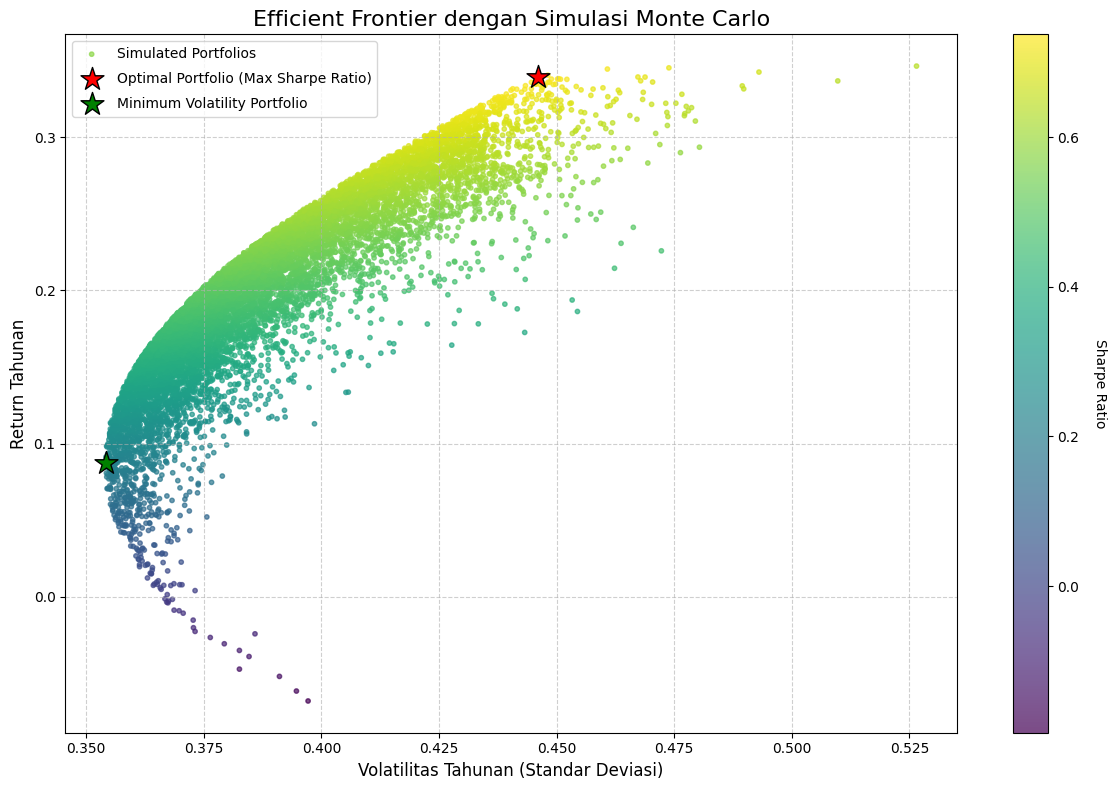

Scatter plot hasil simulasi portofolio telah ditampilkan.


In [ ]:
import seaborn as sns

# 1. Buat scatter plot dari semua portofolio yang disimulasikan
plt.figure(figsize=(12, 8))

# Scatter plot untuk semua portofolio
scatter = plt.scatter(
    portfolio_results['Volatility'],
    portfolio_results['Return'],
    c=portfolio_results['Sharpe Ratio'], # Warna berdasarkan Sharpe Ratio
    cmap='viridis', # Colormap
    marker='o',
    s=10, # Ukuran marker
    alpha=0.7,
    label='Simulated Portfolios'
)

# 2. Tandai portofolio optimal (Sharpe Ratio tertinggi)
plt.scatter(
    optimal_portfolio['Volatility'],
    optimal_portfolio['Return'],
    marker='*', # Penanda bintang
    color='red',
    s=300, # Ukuran lebih besar
    label='Optimal Portfolio (Max Sharpe Ratio)',
    edgecolors='black',
    linewidth=1
)

# 3. Tandai portofolio risiko minimum
plt.scatter(
    min_volatility_portfolio['Volatility'],
    min_volatility_portfolio['Return'],
    marker='*', # Penanda bintang
    color='green',
    s=300, # Ukuran lebih besar
    label='Minimum Volatility Portfolio',
    edgecolors='black',
    linewidth=1
)

# 4. Tambahkan judul plot dan label sumbu
plt.title('Efficient Frontier dengan Simulasi Monte Carlo', fontsize=16)
plt.xlabel('Volatilitas Tahunan (Standar Deviasi)', fontsize=12)
plt.ylabel('Return Tahunan', fontsize=12)

# 5. Tampilkan legenda dan grid
plt.legend(labelspacing=0.8, loc='best')
plt.grid(True, linestyle='--', alpha=0.6)

# Tambahkan color bar untuk Sharpe Ratio
cbar = plt.colorbar(scatter)
cbar.set_label('Sharpe Ratio', rotation=270, labelpad=20)

# Tampilkan plot
plt.tight_layout()
plt.show()

print("Scatter plot hasil simulasi portofolio telah ditampilkan.")